In [8]:
#Modules
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker
#from matplotlib import rc
#import latex

import random
import math
import scipy 
from scipy.optimize import fsolve
from random import uniform

import astropy
from astropy import modeling
from astropy import photutils

In [2]:
#Create a mesh grid to simulate a background of space
#Create the x coordiantes
xCoords = np.linspace(1,50,50)

#Create the y coordinates
yCoords = np.linspace(1,50,50)

#Create a grid
xField, yField = np.meshgrid(xCoords, yCoords)


#Create a new grid using noise
#xCoordsRandom = np.zeros(15)
                         

In [5]:
print(xField)

[[ 1.  2.  3. ... 48. 49. 50.]
 [ 1.  2.  3. ... 48. 49. 50.]
 [ 1.  2.  3. ... 48. 49. 50.]
 ...
 [ 1.  2.  3. ... 48. 49. 50.]
 [ 1.  2.  3. ... 48. 49. 50.]
 [ 1.  2.  3. ... 48. 49. 50.]]


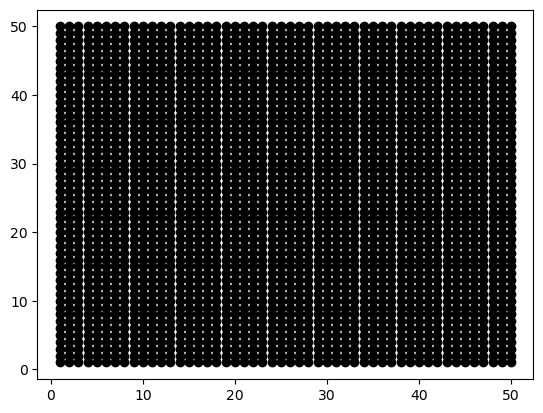

In [7]:
plt.plot(xField, yField, marker = 'o', color = 'k', linestyle = 'none')
plt.show()

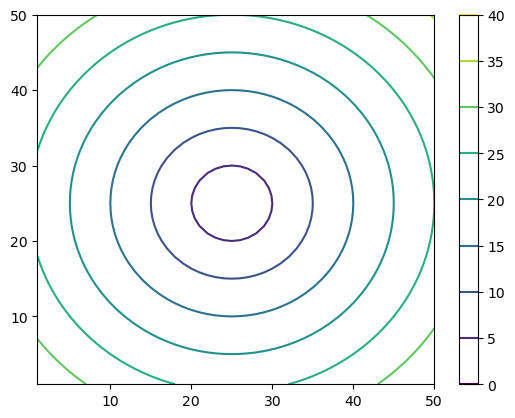

In [9]:
xCenter = 25
yCenter = 25
zField = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)
plt.contour(xCoords, yCoords, zField)
plt.colorbar()
plt.show()

In [129]:
xCoords = np.linspace(1,100,100)

#Create the y coordinates
yCoords = np.linspace(1,100,100)

#Create a grid
xField, yField = np.meshgrid(xCoords, yCoords)

In [131]:
#Define the center of the source
xCenter = 60
yCenter = 60

#Create a meshgrid where all of the pixels are determined by a function of the distance from the source's center; in this case, circular contours
radius = 7
zFieldPrime = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)

#Convert all pixels beyond a predetermined radius of the source to zero
zFieldPrime[zFieldPrime > radius**2] = 0


print(zFieldPrime)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


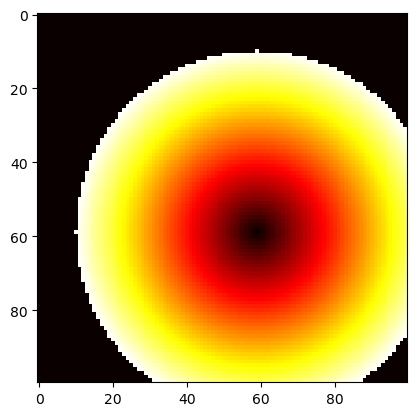

In [133]:
plt.imshow(zFieldPrime, cmap = 'hot')
plt.show()

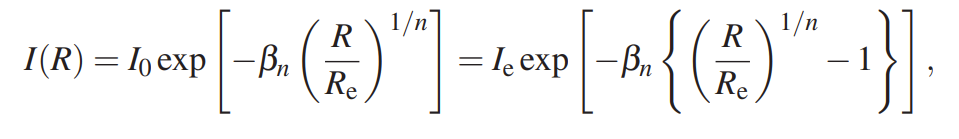

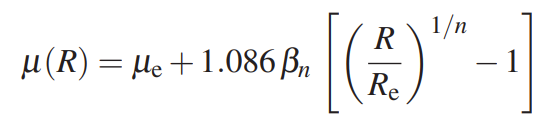

The above equation is that used to plot the surface brightness profile of a spheroidal elliptical galaxy

[[0.70710678 0.70639932 0.70569257 ... 0.70569257 0.70639932 0.70710678]
 [0.70639932 0.70569115 0.70498369 ... 0.70498369 0.70569115 0.70639932]
 [0.70569257 0.70498369 0.70427552 ... 0.70427552 0.70498369 0.70569257]
 ...
 [0.70569257 0.70498369 0.70427552 ... 0.70427552 0.70498369 0.70569257]
 [0.70639932 0.70569115 0.70498369 ... 0.70498369 0.70569115 0.70639932]
 [0.70710678 0.70639932 0.70569257 ... 0.70569257 0.70639932 0.70710678]]


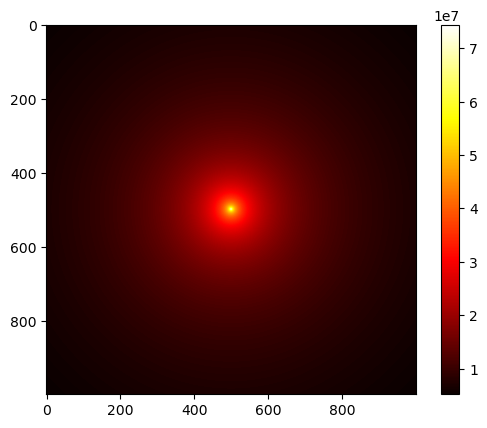

In [5]:
#Ideal elliptical galaxy surface brightness profile (i.e. no noise, and assuming the source is an ideal ellipse/circle)

#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Define the radius away from the center as a meshgrid
r = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)
print(r)

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

#Create a meshgrid for the intensity of the source based upon the distance (r) from the center
#r[r > radius**2] = 0

I = I_o*np.exp(-1*Beta_n*(r/R_e)**(1/n))

plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

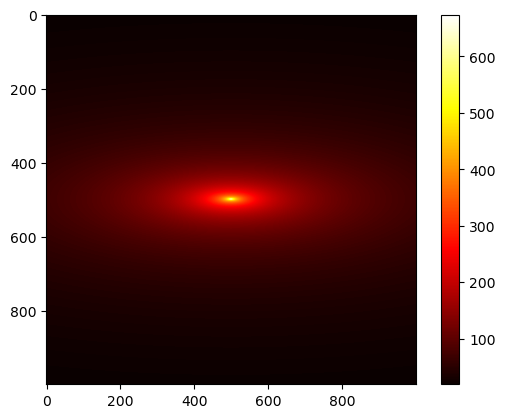

In [7]:
#Surface brightness profile of a non-ideal elliptical galaxy (i.e. the semimajor and semiminor axes aren't equal)
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**3
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

-0.5235987755982988


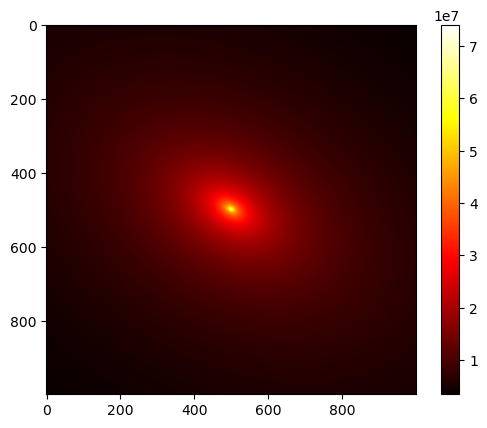

In [11]:
#Surface brightness profile of a non-ideal elliptical galaxy (i.e. the semimajor and semiminor axes aren't equal)
#Now allow for rotation of the ellipse around the center point
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


plt.imshow(I,cmap = 'hot')
plt.colorbar()
plt.show()

-0.5235987755982988


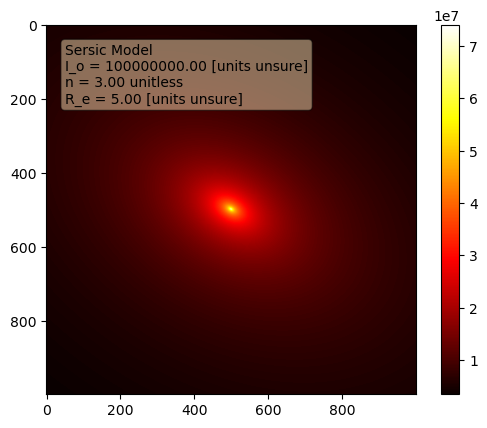

In [5]:
#Surface brightness profile of a non-ideal elliptical galaxy (i.e. the semimajor and semiminor axes aren't equal)
#Using an enhance plot where parameters and model are also shown on the figure
#Now allow for rotation of the ellipse around the center point
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


#Text to be used within the plot's textbox





text = '\n'.join((
    'Sersic Model',
    r'I_o = %.2f [units unsure]' % (I_o,),
    r'n = %.2f unitless' % (n,),
    r'R_e = %.2f [units unsure]' % (R_e,) ))
    
#Properties of the box on which the text is displayed
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.text(50, 50, text, fontsize=10, verticalalignment='top', bbox = props)
plt.show()

-0.5235987755982988


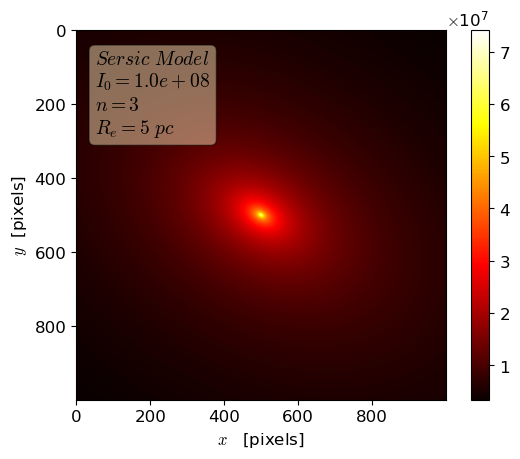

In [96]:
#EXAMPLE PLOT TO USE FOR PLOT MODIFICATIONS AND TESTING


#Surface brightness profile of a non-ideal elliptical galaxy (i.e. the semimajor and semiminor axes aren't equal)
#Using an enhance plot where parameters and model are also shown on the figure
#Now allow for rotation of the ellipse around the center point
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


#Generate a plot



plt.imshow(I, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$   [pixels]')
plt.ylabel(r'$y$  [pixels]')

text = '\n'.join((
    rf'$Sersic \ Model$',
    rf'$I_0 = {I_o:.1e}$ ',
    rf'$n = {n}$',
    rf'$R_e = {R_e} \ pc$'))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)


plt.text(50, 50, text, fontsize=14, verticalalignment='top', bbox = props)
plt.show()

#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
#plt.rcParams['ps.useafm'] = True
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
#plt.rcParams['pdf.fonttype'] = 42



-0.5235987755982988


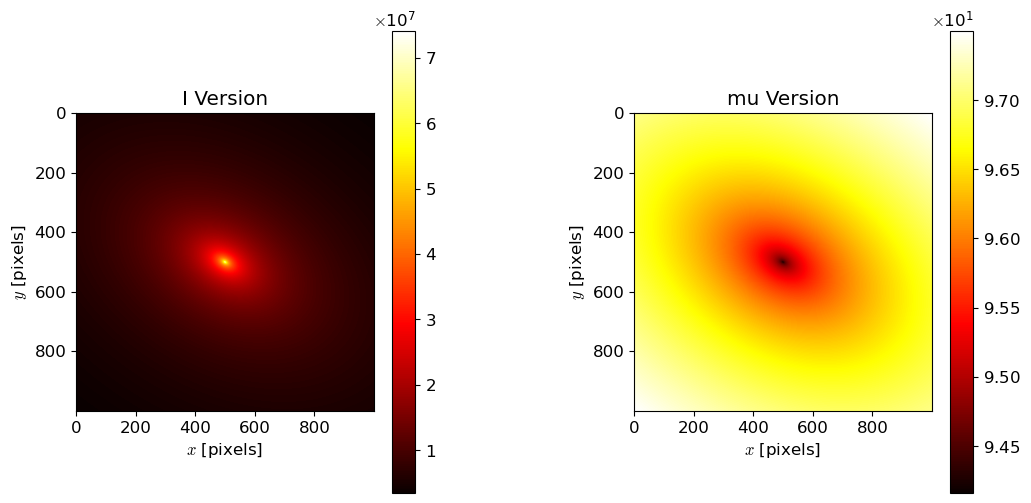

In [134]:
#Example Plot showing both the I and mu versions of surface brightness

xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

mu_e = 10**2

mu = mu_e + 1.086*Beta_n*((a/R_e)**(1/n) - 1)

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,12))
plt.figsize = (16,16)
fig.subplots_adjust(wspace=0.5)

im1 = ax1.imshow(I, cmap = 'hot')
ax1.set_title('I Version')
ax1.set_xlabel('$x$ [pixels]')
ax1.set_ylabel('$y$ [pixels]')
cb1 = fig.colorbar(im1, shrink = 0.5)
cb1.formatter.set_powerlimits((0, 0))
cb1.formatter.set_useMathText(True)
cb1.update_ticks()

im2 = ax2.imshow(mu, cmap = 'hot')
ax2.set_title('mu Version')
ax2.set_xlabel('$x$ [pixels]')
ax2.set_ylabel('$y$ [pixels]')
cb2 = fig.colorbar(im2, shrink = 0.5)
cb2.formatter.set_powerlimits((0, 0))
cb2.formatter.set_useMathText(True)
cb2.update_ticks()

plt.show()

-0.5235987755982988
[[554928.95730664 555545.95569006 556162.53852493 ... 556162.53852493
  555545.95569006 554928.95730664]
 [555545.95569006 556163.77746898 556781.18332766 ... 556781.18332766
  556163.77746898 555545.95569006]
 [556162.53852493 556781.18332766 557399.41183893 ... 557399.41183893
  556781.18332766 556162.53852493]
 ...
 [556162.53852493 556781.18332766 557399.41183893 ... 557399.41183893
  556781.18332766 556162.53852493]
 [555545.95569006 556163.77746898 556781.18332766 ... 556781.18332766
  556163.77746898 555545.95569006]
 [554928.95730664 555545.95569006 556162.53852493 ... 556162.53852493
  555545.95569006 554928.95730664]]


Text(0, 0.5, '$y$  [pixels]')

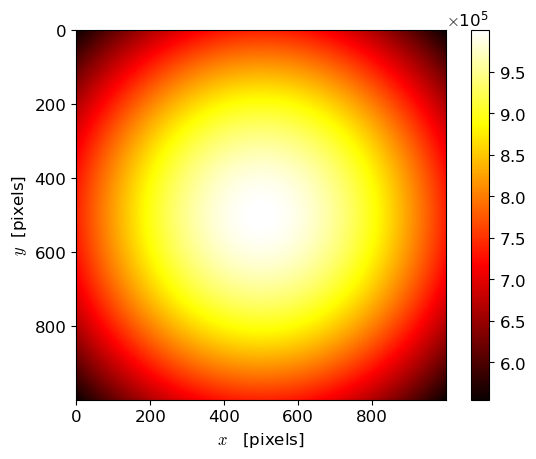

In [30]:
#Add in a 2D Moffat star model

#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

amp = 10**6
gamma = 2
alpha = 5

moffat = astropy.modeling.functional_models.Moffat2D.evaluate(xField, yField, amp, xCenter, yCenter, gamma, alpha)
print(moffat)

#Generate the plot
plt.imshow(moffat, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$   [pixels]')
plt.ylabel(r'$y$  [pixels]')

-0.5235987755982988
3.6651914291880923


Text(0, 0.5, '$y$  [pixels]')

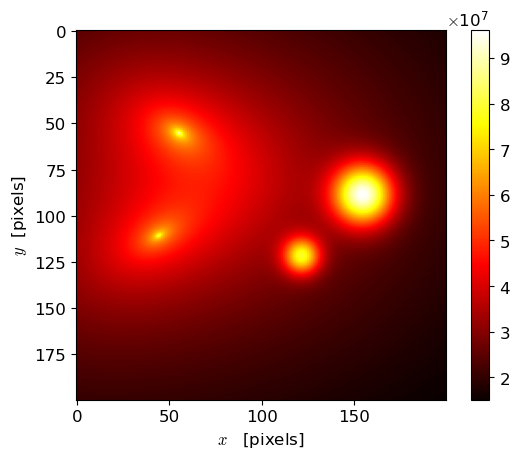

In [152]:
#Throw a 2D moffat model onto an elliptical galaxy image
#Using I function for the elliptical galaxy


#Elliptical Galaxy 1
xCoords = np.linspace(1,10,200)

#Create the y coordinates
yCoords = np.linspace(1,10,200)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter_gal = 3.5
yCenter_gal = 3.5

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = -1*30

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter_gal
deltaY = yField - yCenter_gal

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 100

I1 = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

#Elliptical Galaxy 2

#Define the center of the source
xCenter_gal = 3
yCenter_gal = 6

#Set the eccentricity of the ellipse 
e = 0.8

#Set the angle of rotation (in degrees)
theta = 210

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter_gal
deltaY = yField - yCenter_gal

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 9*10**7
Beta_n = 2*n - 0.324
R_e = 150

I2 = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

#2D Moffat Star Model (1st Star)

xCenter_star1 = 6.5
yCenter_star1 = 6.5

amp1 = 5*10**7
gamma1 = 2
alpha1 = 20

moffat1 = astropy.modeling.functional_models.Moffat2D.evaluate(xField, yField, amp1, xCenter_star1, yCenter_star1, gamma1, alpha1)

#2D Moffat Star Model (2nd Star)

xCenter_star2 = 8
yCenter_star2 = 5

amp2 = 7*10**7
gamma2 = 3
alpha2 = 17

moffat2 = astropy.modeling.functional_models.Moffat2D.evaluate(xField, yField, amp2, xCenter_star2, yCenter_star2, gamma2, alpha2)



#Combine the models

combined_image = I1 + I2 +  moffat1 + moffat2

#Generate the plot
plt.imshow(combined_image, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.xlabel(r'$x$   [pixels]')
plt.ylabel(r'$y$  [pixels]')

This section begins the noise testing section

[[998.11910191 998.11884819 998.11859491 ... 998.11859491 998.11884819
  998.11910191]
 [998.11649614 998.11624165 998.1159876  ... 998.1159876  998.11624165
  998.11649614]
 [998.11388765 998.11363239 998.11337756 ... 998.11337756 998.11363239
  998.11388765]
 ...
 [998.11388765 998.11363239 998.11337756 ... 998.11337756 998.11363239
  998.11388765]
 [998.11649614 998.11624165 998.1159876  ... 998.1159876  998.11624165
  998.11649614]
 [998.11910191 998.11884819 998.11859491 ... 998.11859491 998.11884819
  998.11910191]]


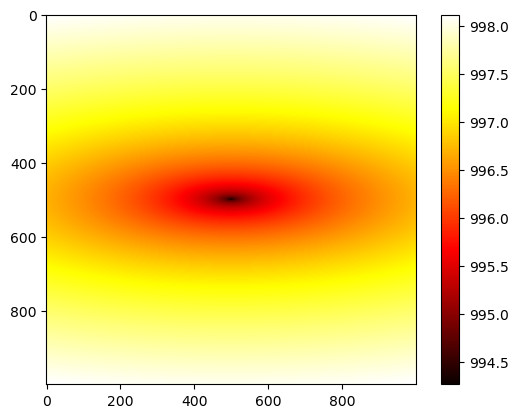

[[140.98257823 140.98257825 140.98257826 ... 140.98257826 140.98257825
  140.98257823]
 [140.9825784  140.98257842 140.98257843 ... 140.98257843 140.98257842
  140.9825784 ]
 [140.98257857 140.98257859 140.9825786  ... 140.9825786  140.98257859
  140.98257857]
 ...
 [140.98257857 140.98257859 140.9825786  ... 140.9825786  140.98257859
  140.98257857]
 [140.9825784  140.98257842 140.98257843 ... 140.98257843 140.98257842
  140.9825784 ]
 [140.98257823 140.98257825 140.98257826 ... 140.98257826 140.98257825
  140.98257823]]
[[9628084.49784044 9628084.49745987 9628084.49707994 ... 9628084.49707994
  9628084.49745987 9628084.49784044]
 [9628084.49393178 9628084.49355005 9628084.49316897 ... 9628084.49316897
  9628084.49355005 9628084.49393178]
 [9628084.49001906 9628084.48963616 9628084.48925392 ... 9628084.48925392
  9628084.48963616 9628084.49001906]
 ...
 [9628084.49001906 9628084.48963616 9628084.48925392 ... 9628084.48925392
  9628084.48963616 9628084.49001906]
 [9628084.49393178 9628

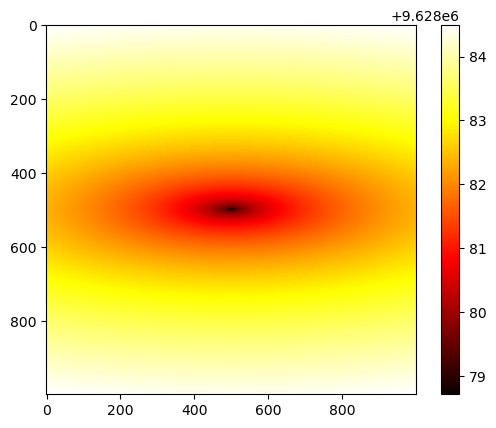

In [33]:
#Surface brightness profile of a non-ideal elliptical galaxy (i.e. the semimajor and semiminor axes aren't equal)
#Now including Poisson noise based upon the ideal image values
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))
print(I)

plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()


#Computing the noise
#Assume that the entire image is 1 arcsecond by 1 arcsecond
#Therefore, since the image is 1000x1000 grid points, each point comprises an area of (1/1000)^2 arcseconds

boxSize = (1/1000)**2

#Convert the surface brightness from mag/arcseconds^2 to mag

mu_mag = mu*boxSize

#Set values for the absolute flux and absolute magnitudes
#Flux is in photons per second per square parsec

m_0 = 0
F_0 = 10**6

#Compute the flux in each grid point (units are photons/s/parsec^2)
power = (m_0 - mu_mag)*(1/2.5)

flux = F_0 * 10**power

#Convert the flux to photons 

#In parsecs
distance = 2

#In seconds
time = 1

photonNumber = flux*time*4*np.pi*distance**2

#Compute the noise following Poisson statistics

photonNoise = np.sqrt(photonNumber)

#Convert the photon noise back to units of mag/arcsecond^2

fluxNoise = photonNoise/(time*4*np.pi*distance**2)

magNoise = m_0 - 2.5*np.log10(fluxNoise/F_0)

muNoise = magNoise/boxSize

#Add the surface brightness noise to the ideal surface brightness and plot

mu_SignalNoise = mu + muNoise
print(mu_SignalNoise)

plt.imshow(mu_SignalNoise, cmap = 'hot')
plt.colorbar()
plt.show()

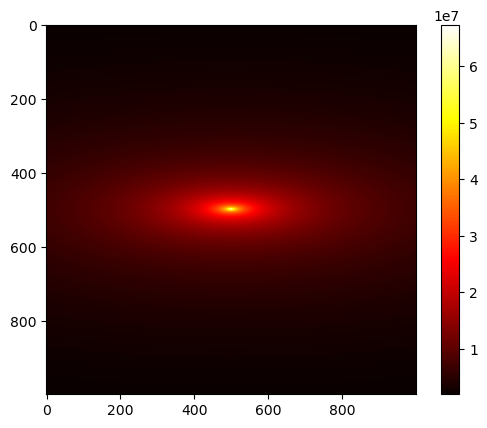

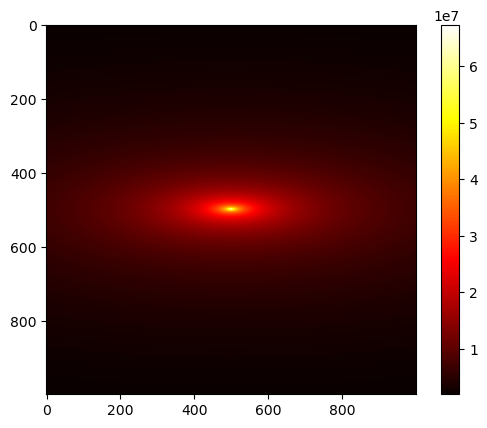

In [7]:
#Try to create noise using the pre-built in functions from Python
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))
#print(I)

plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

#Pass the intensity image I through Numpy's poisson noise function

noise1 = np.random.poisson(I)

#Add the noise to the original image and plot it

compound_image = I + noise1

#print(compound_image)

plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

In [49]:
print(shapeI[0])
print(shapeI[1])

1000
1000


[[790. 702. 514. ...  27. 280. 642.]
 [672. 285. 602. ... 998. 286. 285.]
 [540. 935. 531. ... 816. 876.  20.]
 ...
 [694. 491. 698. ... 574. 260. 171.]
 [748. 212. 338. ... 127. 978. 474.]
 [841. 592. 748. ... 952. 697. 439.]]


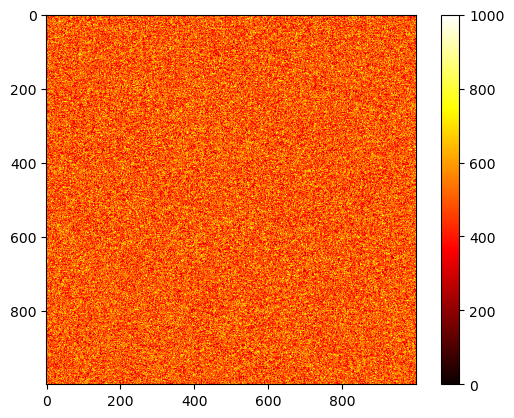

In [32]:
#Create an ideal background image of random emission

xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

blankBackground = 0*xField + 0*yField

#Set the maximum emission value for random noise within the background

randMax = 10**3


#Adjust the background mesh grid to allow for iterating over
backgroundShape = np.shape(blankBackground)

blankBackground = np.ravel(blankBackground)

#Add background emission to each element of the mesh grid
for index in range(len(blankBackground)):
    randomNoise = random.randint(0, randMax)
    blankBackground[index] = randomNoise

#Reshape the background mesh grid to the original shape
blankBackgroundRestored = blankBackground.reshape(backgroundShape)
print(blankBackgroundRestored)

#Plot the background
plt.imshow(blankBackgroundRestored, cmap = 'hot')
plt.colorbar()
plt.show()

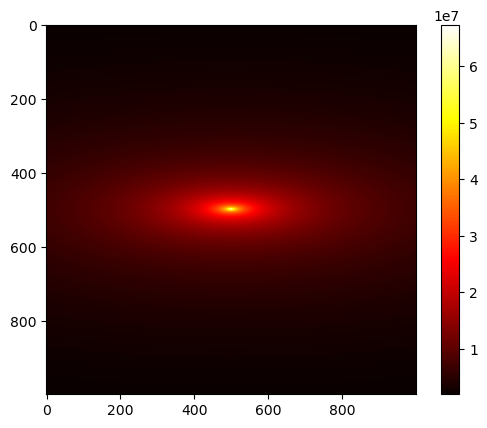

In [57]:
#Testing using intensity of the source
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5


I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

#Plot the intensity
plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

[[1936961.57392027 1937414.14501647 1937866.04831223 ... 1937866.04831223
  1937414.14501647 1936961.57392027]
 [1941614.74239195 1942069.78358101 1942524.15414021 ... 1942524.15414021
  1942069.78358101 1941614.74239195]
 [1946283.94490712 1946741.4731107  1947198.32784308 ... 1947198.32784308
  1946741.4731107  1946283.94490712]
 ...
 [1946283.94490712 1946741.4731107  1947198.32784308 ... 1947198.32784308
  1946741.4731107  1946283.94490712]
 [1941614.74239195 1942069.78358101 1942524.15414021 ... 1942524.15414021
  1942069.78358101 1941614.74239195]
 [1936961.57392027 1937414.14501647 1937866.04831223 ... 1937866.04831223
  1937414.14501647 1936961.57392027]]
[[7202331. 7114310. 8641561. ... 2886738. 7209962.  249983.]
 [6676651.  126759. 5149701. ... 2698421. 7700983. 9357232.]
 [9019501. 6450458. 3757620. ... 3408161. 4810226. 8037760.]
 ...
 [8068226. 6304526. 5269312. ... 8417110. 1325595. 5346377.]
 [7622697. 1450467. 7671093. ... 1693534.   24009. 7626596.]
 [8780478. 6237533

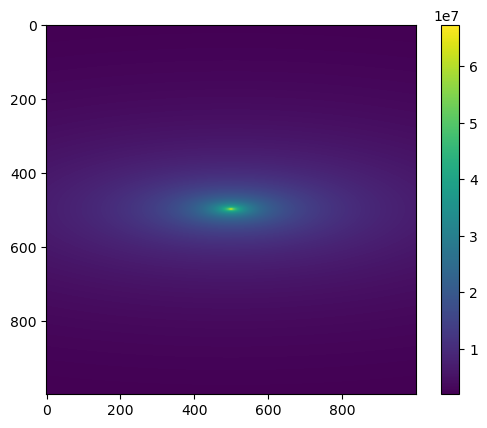

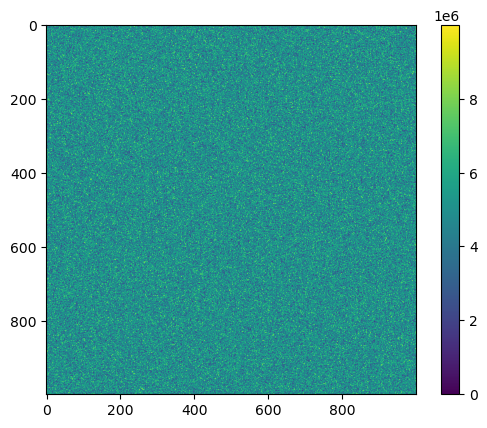

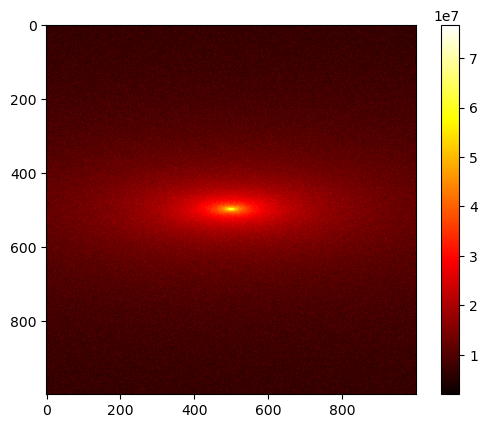

In [71]:
#Combine the emission from the ideal elliptical source with the background emission created previously
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5


I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))
print(I)

blankBackground = 0*xField + 0*yField

#Set the maximum emission value for random noise within the background

randMax = 10**7


#Adjust the background mesh grid to allow for iterating over
backgroundShape = np.shape(blankBackground)

blankBackground = np.ravel(blankBackground)

#Add background emission to each element of the mesh grid
for index in range(len(blankBackground)):
    randomNoise = random.randint(0, randMax)
    blankBackground[index] = randomNoise

#Reshape the background mesh grid to the original shape
blankBackgroundRestored = blankBackground.reshape(backgroundShape)
print(blankBackgroundRestored)

#Combine the background and the source's emission

combined = I + blankBackgroundRestored
print(combined)

plt.imshow(I)
plt.colorbar()
plt.show()

plt.imshow(blankBackgroundRestored)
plt.colorbar()
plt.show()

plt.imshow(combined, cmap = 'hot')
plt.colorbar()
plt.show()

In [ ]:
#Take the above example and add Poisson noise to it
#Combine the emission from the ideal elliptical source with the background emission created previously
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,2,1000)

#Create the y coordinates
yCoords = np.linspace(1,2,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 1.5
yCenter = 1.5

#Set the eccentricity of the ellipse 
e = 0.95

#Solve for the semimajor axis length at all points within the mesh grid

a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 5


I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))
print(I)

blankBackground = 0*xField + 0*yField

#Set the maximum emission value for random noise within the background

randMax = 10**7


#Adjust the background mesh grid to allow for iterating over
backgroundShape = np.shape(blankBackground)

blankBackground = np.ravel(blankBackground)

#Add background emission to each element of the mesh grid
for index in range(len(blankBackground)):
    randomNoise = random.randint(0, randMax)
    blankBackground[index] = randomNoise

#Reshape the background mesh grid to the original shape
blankBackgroundRestored = blankBackground.reshape(backgroundShape)
print(blankBackgroundRestored)

#Combine the background and the source's emission

combined = I + blankBackgroundRestored

plt.imshow(combined, cmap = 'hot')
plt.colorbar()
plt.show()

This section begins the disk galaxy testing

Equation used for the disk/spiral galaxy profile
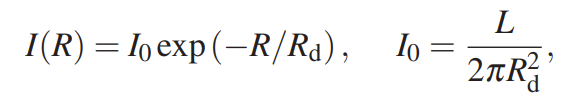

[[26832.68261438 26889.68865843 26946.75115681 ... 21021.6020962
  20972.4172162  20923.3128025 ]
 [26889.68865843 26946.88032154 27004.12890562 ... 21061.13462567
  21011.81383836 20962.57393675]
 [26946.75115681 27004.12890562 27061.56404482 ... 21100.6870268
  21051.23010589 21001.8544917 ]
 ...
 [21021.6020962  21061.13462567 21100.6870268  ... 16889.80016892
  16853.95751431 16818.15872082]
 [20972.4172162  21011.81383836 21051.23010589 ... 16853.95751431
  16818.22318373 16782.5324551 ]
 [20923.3128025  20962.57393675 21001.8544917  ... 16818.15872082
  16782.5324551  16746.94953338]]


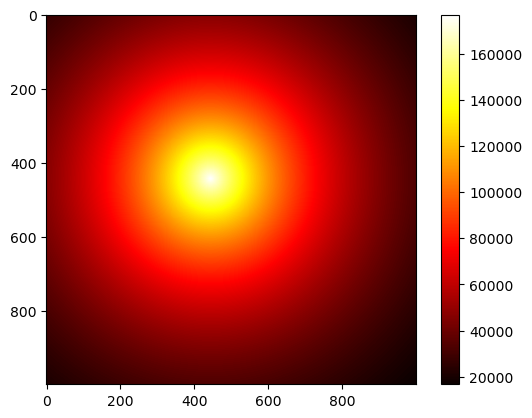

In [19]:
#Disk/spiral galaxy surface brightness profile

#Ideal elliptical galaxy surface brightness profile (i.e. no noise, and assuming the source is an ideal ellipse/circle)

#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,10,1000)

#Create the y coordinates
yCoords = np.linspace(1,10,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 5
yCenter = 5

#Define the radius away from the center as a meshgrid
r = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)

#Set the variables needed to compute the surface brightness profile
R_d = 3
L = 10**7

I_o = L/(2*np.pi*R_d**2)

#Compute the surface brightness profile as a function of radial distance

I = I_o * np.exp(-1*r/R_d)
print(I)

#Plot the surface brightness profile as a heatmap
plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

[[26832.68261438 26889.68865843 26946.75115681 ... 21021.6020962
  20972.4172162  20923.3128025 ]
 [26889.68865843 26946.88032154 27004.12890562 ... 21061.13462567
  21011.81383836 20962.57393675]
 [26946.75115681 27004.12890562 27061.56404482 ... 21100.6870268
  21051.23010589 21001.8544917 ]
 ...
 [21021.6020962  21061.13462567 21100.6870268  ... 16889.80016892
  16853.95751431 16818.15872082]
 [20972.4172162  21011.81383836 21051.23010589 ... 16853.95751431
  16818.22318373 16782.5324551 ]
 [20923.3128025  20962.57393675 21001.8544917  ... 16818.15872082
  16782.5324551  16746.94953338]]


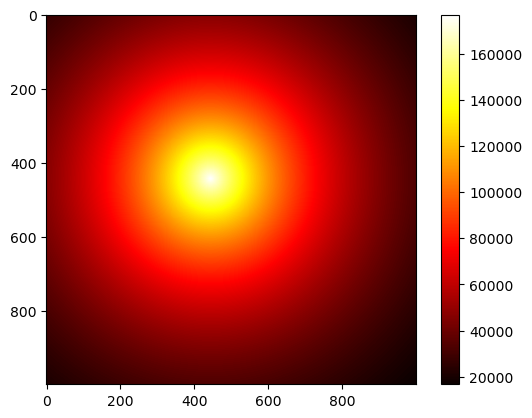

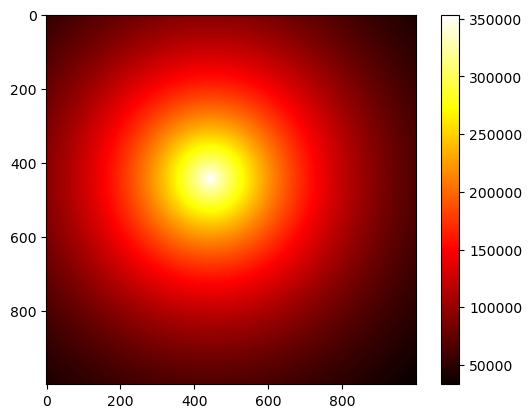

In [65]:
#Create a version of the disk galaxy plot with Poisson noise based on the numpy function
#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,10,1000)

#Create the y coordinates
yCoords = np.linspace(1,10,1000)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 5
yCenter = 5

#Define the radius away from the center as a meshgrid
r = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)

#Set the variables needed to compute the surface brightness profile
R_d = 3
L = 10**7

I_o = L/(2*np.pi*R_d**2)

#Compute the surface brightness profile as a function of radial distance

I = I_o * np.exp(-1*r/R_d)
print(I)

#Plot the surface brightness profile as a heatmap
plt.imshow(I, cmap = 'hot')
plt.colorbar()
plt.show()

#Create the noise mesh grid using Poisson noise
noise = np.random.poisson(I)

#Add the noise to the original image and plot
compound_image = I + noise

plt.imshow(compound_image, cmap = 'hot')
plt.colorbar()
plt.show()


In [11]:
#Insert the advanced galaxy data function here

def createPerfectImage(length, width, ellipticalSourceNumber, diskSourceNumber):

    #Insert variable information here
    
    #Create the blank image based on user-chosen size 
    xCoords = np.linspace(1,length,1000)

    #Create the y coordinates
    yCoords = np.linspace(1,width,1000)

    #Create a grid of coordinates
    xField, yField = np.meshgrid(xCoords, yCoords)

    #Create a blank field to add the images to 
    blank = 0*xField + 0*yField

    #Create a list to store the centers of sources and have a unique identifier for elliptical versus disk galaxies
    #0 will be used for ellipticals, 1 will be used for disks
    center_list = []

    #Create mesh grids corresponding to each elliptical source and add them onto the blank 

    for item in range(0,ellipticalSourceNumber):
        #Define the center of the source
        xCenter = uniform(1,length)
        yCenter = uniform(1,width)

        #Add the source center's coordinates and type to the list

        source_coords = (xCenter, yCenter, 0)

        center_list.append(source_coords)
        
        #Set the eccentricity of the ellipse 
        e = uniform(0,1)
        
        #Solve for the semimajor axis length at all points within the mesh grid
        
        a = np.sqrt((xField - xCenter)**2 + ((yField - yCenter)**2)/(1-e**2))
        
        #Set the variables needed to compute the surface brightness profile
        n = 3
        I_o = 10**8
        Beta_n = 2*n - 0.324
        R_e = 5
        
        I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

        blank = blank + I


    #Create mesh grids to add disk sources to the blank image

    for item in range(0, diskSourceNumber):
        #Define the center of the source
        xCenter = uniform(1,length)
        yCenter = uniform(1,width)

        #Add the source center's coordinates and type to the list

        source_coords = (xCenter, yCenter, 1)

        center_list.append(source_coords)
        
        #Define the radius away from the center as a meshgrid
        r = np.sqrt((xField-xCenter)**2 + (yField-yCenter)**2)
        
        #Set the variables needed to compute the surface brightness profile
        R_d = 3
        L = 5*10**8
        
        I_o = L/(2*np.pi*R_d**2)
        
        #Compute the surface brightness profile as a function of radial distance
        
        I = I_o * np.exp(-1*r/R_d)

        blank = blank + I
    
    plt.imshow(blank, cmap = 'hot')
    plt.colorbar()
    plt.show()    

    #See if using Numpy's poisson distribution makes adding noise easy

    noise = np.random.poisson(blank)

    noisy_image1 = blank + noise


    

    plt.imshow(noisy_image1, cmap = 'hot')
    plt.colorbar()
    plt.show()   

    #Try to do a Poisson error calculation using the derived number of photons
    #We will assume that this image is taken at a distance of 1 pc away, that all of the emission is in a single wavelength,
    #and that the image is 1" by 1" in angular size

    #In pc
    distance = 1

    #Pixel size in arcseconds^2
    pixel_size = (1/1000)**2

    #In W/pc^2
    flux = blank*pixel_size

    #Convert flux to units of energy [W]
    energy = flux*distance**2

    #Find the frequency of the light
    #We will assume this wavelength is in 3.8 microns
    light_speed = 299792458

    wavelength = (3.8*10**(-1*6))

    frequency = light_speed/wavelength

    #Calculate the energy of a photon

    photon_energy = frequency * (6.626*10**(-1*34))

    #Find the total number of photons

    photon_number = energy/photon_energy

    #Use numpy's poisson distribution to sample random noise at each mesh grid point

    photon_noise = np.random.poisson(photon_number)

    #Take the noise back into units of surface brightness

    energy_noise = photon_noise*photon_energy

    flux_noise = energy_noise/(distance**2)

    blank_noise = flux_noise/pixel_size

    noise2 = blank_noise

    #Add the noise into the image and plot

    noisy_image2 = blank + noise2

    plt.imshow(noisy_image2, cmap = 'hot')
    plt.colorbar()
    plt.show()   

    print(center_list)

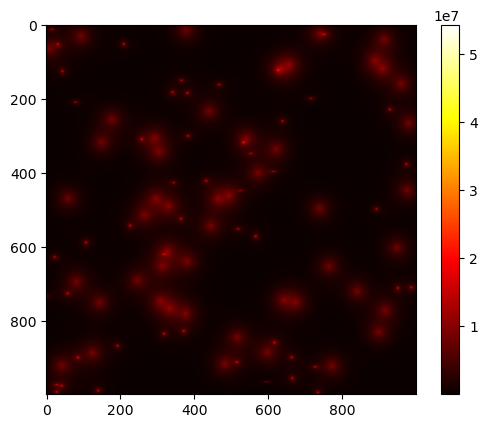

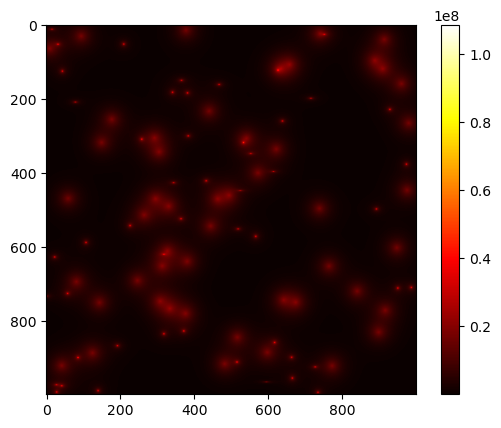

ValueError: lam value too large

In [13]:
createPerfectImage(150, 150, 50, 50)